# Imports and Plot formats

In [2]:
import os, sys, fnmatch, pathlib
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

GSAS_CANDIDATES = [
    "/Users/shane/g2full/GSAS-II",           # repo root (preferred)
    "/Users/shane/g2full/GSAS-II/GSASII",    # inner package (worked before)
]

def _try_import_gsas(cands):
    """Try importing GSASIIscriptable from candidate paths, root first."""
    last_err = None
    for p in cands:
        if p not in sys.path:
            sys.path.insert(0, p)
        try:
            import GSASIIscriptable as _G2
            return _G2, p
        except Exception as e:
            last_err = e
            # remove this candidate and try the next
            try: sys.path.remove(p)
            except Exception: pass
    raise last_err if last_err else ImportError("GSASIIscriptable not found in candidates")

def _find_gsas_bin(start_dir):
    """Search under start_dir (and a few common dirs) for compiled GSAS-II binaries (pypowder*)."""
    roots = [
        start_dir,
        os.path.dirname(start_dir),  # if we imported from .../GSASII, also try its parent
        os.path.expanduser("~/Library/Application Support/GSAS-II"),
        os.path.expanduser("~/gsas2"),
    ]
    patterns = ("pypowder*.so", "pypowder*.dylib", "pypowder*.pyd")
    seen = set()
    for r in roots:
        r = os.path.abspath(r)
        if not os.path.isdir(r) or r in seen:
            continue
        seen.add(r)
        for dirpath, _, filenames in os.walk(r):
            if any(any(fnmatch.fnmatch(f, pat) for pat in patterns) for f in filenames):
                return dirpath
    return None

G2, used_path = _try_import_gsas(GSAS_CANDIDATES)
print(f"Imported GSASIIscriptable from: {used_path}")

bin_dir = None
try:
    from GSASII import GSASIIpath
    bin_dir = GSASIIpath.GetConfigValue('binDir')
except Exception:
    GSASIIpath = None

if not bin_dir or not os.path.isdir(bin_dir):
    
    guess_root = used_path
    if guess_root.rstrip("/").endswith("/GSASII"):
        guess_root = os.path.dirname(guess_root)
    auto_bin = _find_gsas_bin(guess_root)
    if auto_bin:
        os.environ["GSASII_BIN"] = auto_bin
        if GSASIIpath:
            try:
                GSASIIpath.SetBinaryPath(auto_bin)
            except Exception:
                pass
        print("GSAS-II bin set to:", auto_bin)
    else:
        print("⚠️ Could not auto-locate GSAS-II binaries (pypowder). "
              "Imports may work but profile calcs could be disabled.")
else:
    print("GSAS-II bin already configured:", bin_dir)

# 4) Quick diagnostics
print("Python exe:", sys.executable)
print("GSAS-II module file:", pathlib.Path(G2.__file__).as_posix())

# 5) Create/open a project (adjust name/path as desired)
proj = G2.G2Project(newgpx='WC_cubic_eva.gpx')
print("New GSAS-II project created:", proj.filename)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Module pyspg in '/Users/shane/g2full/GSAS-II/GSASII-bin/mac_arm_p3.11_n1.26' could not be loaded
error msg: dlopen(/Users/shane/g2full/GSAS-II/GSASII-bin/mac_arm_p3.11_n1.26/pyspg.cpython-311-darwin.so, 0x0002): tried: '/Users/shane/g2full/GSAS-II/GSASII-bin/mac_arm_p3.11_n1.26/pyspg.cpython-311-darwin.so' (mach-o file, but is an incompatible architecture (have 'arm64', need 'x86_64')), '/System/Volumes/Preboot/Cryptexes/OS/Users/shane/g2full/GSAS-II/GSASII-bin/mac_arm_p3.11_n1.26/pyspg.cpython-

In [60]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import urllib.request

urllib.request.urlretrieve(
    "https://github.com/google/fonts/raw/main/ofl/ibmplexmono/IBMPlexMono-Regular.ttf",
    "IBMPlexMono-Regular.ttf",
)
fe = font_manager.FontEntry(fname="IBMPlexMono-Regular.ttf", name="plexmono")
font_manager.fontManager.ttflist.append(fe)
plt.rcParams.update(
    {
        "axes.facecolor": "#f5f4e9",
        "grid.color": "#AAAAAA",
        "axes.edgecolor": "#333333",
        "figure.facecolor": "#FFFFFF",
        "axes.grid": False,
        "axes.prop_cycle": plt.cycler("color", plt.cm.Dark2.colors),
        "font.family": fe.name,
        "figure.figsize": (3.5, 3.5 / 1.2),
        "ytick.left": True,
        "xtick.bottom": True,
    }
)



# Create System Message

In [ ]:
import pandas as pd
import re
import json
from openai import OpenAI

# Initialize the GPT-4o (or GPT-4) client
client = OpenAI()

# File paths
input_file_path = "/Users/shane/xrd_to_lyft/refined_recipes_residuals.csv"
output_file_path = "/Users/shane/xrd_to_lyft/extracted_params.csv"
failed_log_path = "/Users/shane/xrd_to_lyft/parameter_extraction_failures.log"

# Function to call GPT-4o and parse out parameters as JSON
def extract_parameters_with_gpt(recipe_text):
    """
    Use GPT-4o (or GPT-4) to parse the synthesis procedure text 
    and extract relevant parameters as strict JSON.
    """

    # System prompt
    system_prompt = (
        "You are an expert in zeolite or catalyst synthesis. "
        "Parse the procedure text and extract relevant parameters (e.g., temperature, time, precursors, etc.). "
        "Return only valid JSON with keys and values (no extra commentary)."
    )

    # User prompt
    user_prompt = f"""
Procedure:

{recipe_text}

Return the extracted parameters in valid JSON only (no code fences).
"""


    response = client.chat.completions.create(
        model="gpt-4o", # never use "gpt-4" here
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        max_tokens=500,
        temperature=0.0,
    )

    if not response.choices or not response.choices[0].message.content:
        raise ValueError("GPT returned an empty or invalid response.")

    raw_answer = response.choices[0].message.content.strip()

    cleaned_answer = re.sub(r"```(?:json)?", "", raw_answer)  
    cleaned_answer = re.sub(r"```", "", cleaned_answer)

    try:
        extracted_params = json.loads(cleaned_answer)
        return extracted_params
    except json.JSONDecodeError:
        raise ValueError(f"Failed to parse JSON from GPT response:\n{raw_answer}")


data = pd.read_csv(input_file_path)


if "extracted_params" not in data.columns:
    data["extracted_params"] = ""

failed_extractions = []

for idx, row in data.iterrows():
    try:
        recipe = row.get("prompt", "")
        if pd.isna(recipe) or len(recipe.strip()) == 0:
            print(f"Skipping row {idx}: No prompt found.")
            failed_extractions.append(f"Row {idx} - No prompt")
            continue

        
        extracted = extract_parameters_with_gpt(recipe)
        data.at[idx, "extracted_params"] = extracted
        print(f"Extracted parameters for row {idx}")

    except Exception as e:
        print(f"Parameter extraction failed for row {idx}: {e}")
        failed_extractions.append(f"Row {idx} - {e}")

data.to_csv(output_file_path, index=False)
print(f"Extracted parameters saved to {output_file_path}")

with open(failed_log_path, "w") as log_file:
    for entry in failed_extractions:
        log_file.write(f"{entry}\n")

print(f"Parameter extraction failures saved to {failed_log_path}")


Extracted parameters for row 0
Extracted parameters for row 1
Extracted parameters for row 2
Extracted parameters for row 3
Extracted parameters for row 4
Extracted parameters for row 5
Extracted parameters for row 6
Extracted parameters for row 7
Extracted parameters for row 8
Extracted parameters for row 9
Extracted parameters for row 10
Extracted parameters for row 11
Extracted parameters for row 12
Extracted parameters for row 13
Parameter extraction failed for row 14: Failed to parse JSON from GPT response:
{
  "precursors": [
    "(-)-cis-myrtanylamine",
    "methanol",
    "potassium carbonate (K2CO3)",
    "methyliodide",
    "chloroform",
    "n-hexane",
    "Amberlite IRN-78 OH anion exchange resin",
    "sodium borate decahydrate",
    "sodium hydroxide",
    "fumed silica"
  ],
  "quantities": {
    "(-)-cis-myrtanylamine": "10 g",
    "methanol": "40 mL",
    "potassium carbonate (K2CO3)": "10.47 g",
    "methyliodide": "21.95 g",
    "methanol wash": "20 mL",
    "chlorof

# GSAS 2 refinement

In [ ]:
# import os
# import re
# import numpy as np
# import pandas as pd

# def clean_filename(name):
#     if not isinstance(name, str) or pd.isna(name):
#         return None
#     name = re.sub(r'[\\/*?:"<>|]', '', name)
#     name = re.sub(r'\s+', '_', name)
#     return name.strip()


# def save_all_xye_and_update_df(df, output_dir='xye_outputs'):
#     os.makedirs(output_dir, exist_ok=True)
#     paths = []

#     for idx, row in df.iterrows():
#         label = row["First Div Text"]
#         clean_label = clean_filename(label) or f"pattern_{idx}"
#         filename = f"{clean_label}.xye"
#         path = os.path.join(output_dir, filename)

#         # Parse and save .xye
#         raw = row["XRD Data (x, y pairs)"]
#         try:
#             pairs = [tuple(map(float, pt.split(','))) for pt in raw.split(';') if ',' in pt]
#             data = np.array(pairs)
#             x, y = data[:, 0], data[:, 1]
#             e = np.sqrt(np.maximum(y, 1e-6))

#             with open(path, 'w') as f:
#                 for xi, yi, ei in zip(x, y, e):
#                     f.write(f"{xi:.5f} {yi:.2f} {ei:.2f}\n")

#             paths.append(path)
#         except Exception as e:
#             print(f"Row {idx} ({label}) failed: {e}")
#             print(f"Raw XRD Data: {raw[:100]}...")  # Only print the first 100 characters to keep it readable
#             paths.append(None)


#     df["xye_file_path"] = paths
#     print(f"Saved {len(paths)} .xye files to '{output_dir}/'")
#     return df


# The working class

# CIF format conversion for gsas2 

In [ ]:
import re
from pathlib import Path

# Load the content of the uploaded CIF file
file_path = Path("./UOS.cif_")
with open(file_path, 'r') as file:
    cif_content = file.read()

# Extract cell parameters and format them
cell_params = {}
for key in [
    '_cell_length_a', '_cell_length_b', '_cell_length_c',
    '_cell_angle_alpha', '_cell_angle_beta', '_cell_angle_gamma'
]:
    match = re.search(rf"{key}\s+([\d.]+)", cif_content)
    if match:
        # Pad like reference format
        cell_params[key] = f"{float(match.group(1)):>10.4f}(0)"

# Extract space group
space_group_match = re.search(r"_symmetry_space_group_name_H-M\s+'([^']+)'", cif_content)
space_group = space_group_match.group(1) if space_group_match else "P 1"

# Symmetry operations (optional fallback)
sym_ops_match = re.findall(r"_symmetry_equiv_pos_as_xyz\s+(.*?)\n\n", cif_content, re.DOTALL)
sym_ops = re.findall(r"'([^']+)'", sym_ops_match[0]) if sym_ops_match else ["+x,+y,+z"]

# Extract atom lines from the final loop block
atom_section = cif_content.split("loop_")[-1]
atom_lines = atom_section.strip().splitlines()
atom_lines_cleaned = []

for line in atom_lines:
    if re.match(r'^\s*[A-Za-z]+\d*\s+[A-Za-z]+\s+[\d\.\-]+', line):
        parts = line.split()[:5]
        if len(parts) == 5:
            label, typ, x, y, z = parts
            formatted_line = f"{label:>6} {typ:>4} {float(x):>10.4f} {float(y):>8.4f} {float(z):>8.4f}"
            atom_lines_cleaned.append(formatted_line)

# Build the GSAS2-style output
formatted_output = [
    "data_UOS",
    "#**************************************************************************",
    "#",
    "# CIF taken from the IZA-SC Database of Zeolite Structures",
    "# Ch. Baerlocher and L.B. McCusker",
    "# Database of Zeolite Structures: http://www.iza-structure.org/databases/ ",
    "#",
    "# The atom coordinates and the cell parameters were optimized with DLS76",
    "# assuming a pure SiO2 composition.",
    "#",
    "#**************************************************************************",
    "",
    f"_cell_length_a                  {cell_params['_cell_length_a']}",
    f"_cell_length_b                  {cell_params['_cell_length_b']}",
    f"_cell_length_c                  {cell_params['_cell_length_c']}",
    f"_cell_angle_alpha               {cell_params['_cell_angle_alpha']}",
    f"_cell_angle_beta                {cell_params['_cell_angle_beta']}",
    f"_cell_angle_gamma               {cell_params['_cell_angle_gamma']}",
    "",
    f"_symmetry_space_group_name_H-M     '{space_group}'",
    "_symmetry_Int_Tables_number         63",
    "_symmetry_cell_setting             orthorhombic",
    "",
    "loop_",
    "_symmetry_equiv_pos_as_xyz"
]

formatted_output += [f"'{op}'" for op in sym_ops]

formatted_output += [
    "",
    "loop_",
    "_atom_site_label",
    "_atom_site_type_symbol",
    "_atom_site_fract_x",
    "_atom_site_fract_y",
    "_atom_site_fract_z"
]
formatted_output += atom_lines_cleaned

# Save to file
formatted_str = "\n".join(formatted_output)
final_output_path = "./UOS_gsas2_refstyle.cif"
with open(final_output_path, 'w') as f:
    f.write(formatted_str)

print("Saved to:", final_output_path)


Saved to: ./UOS_gsas2_refstyle.cif


Retrieving MaterialsDoc documents: 100%|██████████| 1/1 [00:00<00:00, 22192.08it/s]


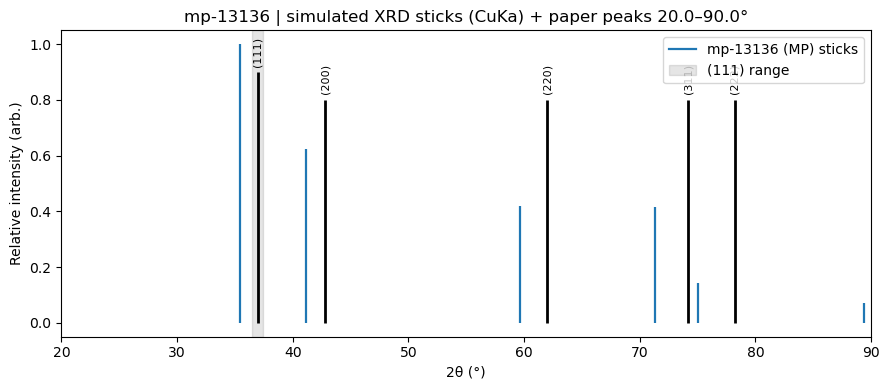

In [5]:
# --- minimal "characteristic peaks" stick plot from Materials Project + paper peaks ---
from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
import matplotlib.pyplot as plt
import numpy as np

API_KEY = "icBTDJ2BXm8nU6Seb9eLTrheDmb9jq2O"  # or: import os; API_KEY = os.environ["MATERIALS_PROJECT_API_KEY"]
mpid = "mp-13136"                   # cubic WC_y example
wavelength = "CuKa"                 # "CuKa", "CuKa1", or numeric Å
two_theta_range = (20.0, 90.0)      # deg 2θ
peak_scale = 1.0                    # height scale for MP sticks

# --- fetch structure and simulate MP sticks ---
with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(mpid)
conv = SpacegroupAnalyzer(structure, symprec=1e-3).get_conventional_standard_structure()
calc = XRDCalculator(wavelength=wavelength)
pat = calc.get_pattern(conv, two_theta_range=two_theta_range)

x = np.array(pat.x); y = np.array(pat.y)
if y.size > 0:
    y = y / y.max() * peak_scale

plt.figure(figsize=(9, 4))

# MP simulated sticks
for xi, yi in zip(x, y):
    plt.vlines(xi, 0, yi, linewidth=1.6, label=None)
plt.plot([], [], linewidth=1.6, label=f"{mpid} (MP) sticks")

# --- Add paper's characteristic cubic-WC_y peaks (2θ, Cu Kα) ---
# Nominal positions reported for cubic WC_y: (111) ~ 37.42° (shifts down to ~36.49° with more C),
# and (200)=42.8°, (220)=62.0°, (311)=74.2°, (222)=78.2°.
paper_peaks = {
    "(200)": 42.8,
    "(220)": 62.0,
    "(311)": 74.2,
    "(222)": 78.2,
}
# Draw the fixed-position sticks (heights set to 0.8 of MP scale)
for hkl, tth in paper_peaks.items():
    plt.vlines(tth, 0, 0.8*peak_scale, linewidth=2.0, color="black")
    plt.text(tth, 0.82*peak_scale, hkl, ha="center", va="bottom", fontsize=8, rotation=90, color="black")

# 111 peak: reported to vary ~36.49–37.42°; draw a band + center marker
tth_111_min, tth_111_max = 36.49, 37.42
tth_111_mid = 0.5*(tth_111_min + tth_111_max)
plt.axvspan(tth_111_min, tth_111_max, color="black", alpha=0.1, label="(111) range")
plt.vlines(tth_111_mid, 0, 0.9*peak_scale, color="black", linewidth=2.0)
plt.text(tth_111_mid, 0.92*peak_scale, "(111)", ha="center", va="bottom", fontsize=8, rotation=90, color="black")

# Finish plot
plt.title(f"{mpid} | simulated XRD sticks ({wavelength}) + paper peaks {two_theta_range[0]}–{two_theta_range[1]}°")
plt.xlabel(r"2θ (°)")
plt.ylabel("Relative intensity (arb.)")
plt.xlim(two_theta_range)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


In [11]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import urllib.request

urllib.request.urlretrieve(
    "https://github.com/google/fonts/raw/main/ofl/ibmplexmono/IBMPlexMono-Regular.ttf",
    "IBMPlexMono-Regular.ttf",
)
fe = font_manager.FontEntry(fname="IBMPlexMono-Regular.ttf", name="plexmono")
font_manager.fontManager.ttflist.append(fe)
plt.rcParams.update(
    {
        "axes.facecolor": "#f5f4e9",
        "grid.color": "#AAAAAA",
        "axes.edgecolor": "#333333",
        "figure.facecolor": "#FFFFFF",
        "axes.grid": False,
        "axes.prop_cycle": plt.cycler("color", plt.cm.Dark2.colors),
        "font.family": fe.name,
        "figure.figsize": (3.5, 3.5 / 1.2),
        "ytick.left": True,
        "xtick.bottom": True,
    }
)


# Modify CIF

In [ ]:
from pathlib import Path
import os

API_KEY = os.environ["MP_API_KEY"]

from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.io.cif import CifWriter
from pymatgen.core import Lattice, Structure

# Where to save files (change this to something obvious like Downloads)
out_dir = Path.home() / "Downloads" / "cifs"
out_dir.mkdir(parents=True, exist_ok=True)

mpid = "mp-13136"  # cubic WC (rock-salt) entry

# fetch MP structure
with MPRester(API_KEY) as mpr:
    s = mpr.get_structure_by_material_id(mpid)

# convert to conventional cell
s_conv = SpacegroupAnalyzer(s, symprec=1e-3).get_conventional_standard_structure()

# write the original MP CIF (conventional)
cif1 = out_dir / "mp-13136_conventional.cif"
CifWriter(s_conv).write_file(cif1)
print(f"Wrote: {cif1.resolve()}")

# OPTIONAL: write a pre-scaled CIF with a = 4.23 Å
target_a = 4.23  # Å
s_scaled = Structure(
    Lattice.cubic(target_a),
    s_conv.species,
    s_conv.frac_coords,
    site_properties=s_conv.site_properties,
)
cif2 = out_dir / "mp-13136_conventional_a4p23.cif"
CifWriter(s_scaled).write_file(cif2)
print(f"Wrote: {cif2.resolve()}")


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/shane/opt/anaconda3/envs/DECIMER/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Retrieving MaterialsDoc documents: 100%|██████████| 1/1 [00:00<00:00, 6710.89it/s]

Wrote: /Users/shane/Downloads/cifs/mp-13136_conventional.cif
Wrote: /Users/shane/Downloads/cifs/mp-13136_conventional_a4p23.cif


# Attempt 2

In [32]:
# CLEAN .XYE FILES -> *_gsas.xye, THEN REFINE ONE CIF vs MANY PATTERNS
import os, sys, math, re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- 0) Bootstrap (same env you already verified) ---
GSAS_ROOT = "/Users/shane/g2full/GSAS-II"
if GSAS_ROOT not in sys.path:
    sys.path.insert(0, GSAS_ROOT)
os.environ.setdefault("GSASII_BIN", "/Users/shane/g2full/GSAS-II/GSASII-bin/mac_arm_p3.11_n1.26")

import GSASIIscriptable as G2sc
try:
    from GSASII import GSASIIobj as G2obj    # to list readers
except Exception:
    G2obj = None

# --- 1) USER PATHS ---
data_dir = Path("/Users/shane/repos/boicl_crystal_phase_isolation/W_xrd_idex")
cif_path  = Path("/Users/shane/repos/boicl_crystal_phase_isolation/mp-13136_conventional_a4p23.cif")
instrument_file = "/Users/shane/xrd_to_lyft/default_instrument.instprm"
SHOW_PLOTS = True

assert data_dir.is_dir(), f"Missing data_dir: {data_dir}"
assert cif_path.is_file(), f"Missing CIF: {cif_path}"
assert os.path.isfile(instrument_file), f"Missing instrument file: {instrument_file}"

# --- 2) CLEANER: write audited *_gsas.xye (X Y SIGMA) but import the originals
def _parse3(line: str):
    s = line.strip().replace(",", " ")
    if not s or s.startswith("#"):
        return None
    parts = [p for p in s.split() if p]
    if len(parts) < 2:
        return None
    try:
        x = float(parts[0]); y = float(parts[1])
        e = float(parts[2]) if len(parts) > 2 else None
        return x, y, e
    except Exception:
        return None

def clean_xye(in_path: Path, out_path: Path):
    xs, ys, es = [], [], []
    with open(in_path, "r", errors="ignore") as f:
        for raw in f:
            t = _parse3(raw)
            if t is None:
                continue
            x,y,e = t
            if not (np.isfinite(x) and np.isfinite(y) and (e is None or np.isfinite(e))):
                continue
            xs.append(x); ys.append(y); es.append(e)
    xs = np.asarray(xs, float); ys = np.asarray(ys, float)
    es = np.asarray([np.nan if e is None else e for e in es], float)

    good = np.isfinite(xs) & np.isfinite(ys)
    xs, ys, es = xs[good], ys[good], es[good]
    if xs.size < 5:
        raise ValueError(f"too few points after cleaning in {in_path.name}")

    order = np.argsort(xs); xs, ys, es = xs[order], ys[order], es[order]
    sigma = np.where(np.isfinite(es) & (es > 0), es, np.sqrt(np.clip(ys, 1e-12, None)))
    sigma = np.clip(sigma, 1e-9, None)  # avoid zero sigma

    with open(out_path, "w") as g:
        for xi, yi, si in zip(xs, ys, sigma):
            g.write(f"{xi:.6f} {yi:.6f} {si:.6f}\n")
    return xs.size, float(xs.min()), float(xs.max())

# originals only (W#.xye)
raw_files = sorted([p for p in data_dir.glob("*.xye") if re.fullmatch(r"W\d+\.xye", p.name)])
if not raw_files:
    raise FileNotFoundError(f"No original W#.xye files in {data_dir}")

print(f"Cleaning {len(raw_files)} .xye files...")
for p in raw_files:
    out = p.with_name(p.stem + "_gsas.xye")
    try:
        npts, xmin, xmax = clean_xye(p, out)
        print(f"  ✓ {p.name} -> {out.name}  (n={npts}, 2θ={xmin:.3f}-{xmax:.3f}°)")
    except Exception as e:
        print(f"  ✗ {p.name} skipped: {e}")

# --- 3) Which reader names exist on this install?
def get_powder_reader_names():
    names = []
    if G2obj is not None:
        try:
            impmap = getattr(G2obj, "ImportExportMap", {})
            for cls in impmap.get("Powder Data", []):
                nm = getattr(cls, "formatName", None)
                if nm:
                    names.append(nm)
        except Exception:
            pass
    # append extra candidates if missing
    for c in ["FullProf FXYE", "Topas XYE", "Fit2D XYE", "XYE", "FXYE", "fullprof fxye", "xye"]:
        if c not in names:
            names.append(c)
    # dedup preserve order
    seen=set(); out=[]
    for n in names:
        if n not in seen:
            out.append(n); seen.add(n)
    return out

available_names = get_powder_reader_names()
print("\nPowder readers (formatName) available/assumed on this install:")
for n in available_names:
    print("  -", n)

# Try hints in this order
HINT_ORDER = [
    "FullProf FXYE", "FXYE", "fullprof fxye",
    "Topas XYE", "Fit2D XYE", "XYE", "xye"
]

def _preview(path, n=3):
    try:
        with open(path, "r", errors="ignore") as f:
            lines=[]
            for _ in range(n):
                line = next(f, None)
                if line is None: break
                lines.append(line.rstrip())
        if lines:
            print("    preview:\n" + "\n".join(lines))
    except Exception:
        pass

def add_hist_safely(gpx, filepath: Path, inst_file: str):
    # Quick sniff: does file appear 3-col?
    is_three = False; seen=0
    with open(filepath, "r", errors="ignore") as f:
        for line in f:
            t = _parse3(line)
            if t is None: continue
            seen += 1
            if t[2] is not None:
                is_three = True
            if seen >= 5: break

    # 0) original, no hint
    try:
        print(f"  → Trying [orig] {filepath.name} (no hint)")
        _preview(filepath)
        h = gpx.add_powder_histogram(str(filepath), inst_file)
        print("    ✓ imported with no hint")
        return h
    except Exception as e:
        print(f"    ✗ [orig] failed: {e}")

    # 1) try all hint spellings that exist (or we added)
    for hint in HINT_ORDER:
        if hint not in available_names and hint not in {"FXYE","fullprof fxye","xye"}:
            continue
        try:
            print(f"  → Trying [hint='{hint}'] {filepath.name}")
            _preview(filepath)
            h = gpx.add_powder_histogram(str(filepath), inst_file, fmthint=hint)
            print(f"    ✓ imported with hint '{hint}'")
            return h
        except Exception as e:
            print(f"    ✗ [hint='{hint}'] failed: {e}")

    # 2) if it’s 3-col, write an .fxye twin (X Y sigma) and try again
    if is_three:
        fxye = filepath.with_suffix(".fxye")
        try:
            print(f"  → Creating temp {fxye.name} (X Y sigma)")
            with open(filepath, "r", errors="ignore") as fin, open(fxye, "w") as fout:
                for raw in fin:
                    t = _parse3(raw)
                    if t is None: continue
                    x,y,e = t
                    if not (np.isfinite(x) and np.isfinite(y)): continue
                    s = e if (e is not None and np.isfinite(e) and e>0) else math.sqrt(max(y,1e-12))
                    fout.write(f"{x:.6f} {y:.6f} {s:.6f}\n")
            _preview(fxye)
            # try no hint then FullProf
            try:
                print(f"  → Trying [fxye no hint] {fxye.name}")
                h = gpx.add_powder_histogram(str(fxye), inst_file)
                print("    ✓ imported fxye with no hint")
                return h
            except Exception as e:
                print(f"    ✗ [fxye no hint] failed: {e}")
            for hint in ["FullProf FXYE","FXYE","fullprof fxye"]:
                try:
                    print(f"  → Trying [hint='{hint}'] {fxye.name}")
                    h = gpx.add_powder_histogram(str(fxye), inst_file, fmthint=hint)
                    print(f"    ✓ imported fxye with hint '{hint}'")
                    return h
                except Exception as e:
                    print(f"    ✗ [fxye hint='{hint}'] failed: {e}")
        finally:
            # keep it for inspection if import ultimately fails
            pass

    # 3) last resort: 2-col temp (X Y)
    try:
        tmp2 = filepath.with_suffix(".tmp2col.xye")
        print(f"  → Building fallback 2-col: {tmp2.name}")
        with open(filepath, "r", errors="ignore") as fin, open(tmp2, "w") as fout:
            for raw in fin:
                t = _parse3(raw)
                if t is None: continue
                x,y,_ = t
                if not (np.isfinite(x) and np.isfinite(y)): continue
                fout.write(f"{x:.6f} {y:.6f}\n")
        _preview(tmp2)
        print(f"  → Trying [2col] {tmp2.name}")
        h = gpx.add_powder_histogram(str(tmp2), inst_file)
        print("    ✓ imported 2-col")
        return h
    except Exception as e:
        print(f"    ✗ [2col] failed: {e}")
        raise
    finally:
        try: tmp2.unlink()
        except Exception: pass

# --- 4) Refinement loop
gpx = G2sc.G2Project(newgpx=str(data_dir / "batch_refine.gpx"))
summary_path = data_dir / "refinement_summary.csv"
with open(summary_path, "w") as csv:
    csv.write("Pattern,Rwp(%),Rf(%),Rf^2(%),Chi^2,FWHM(deg),Error\n")

def estimate_fwhm(hist):
    try:
        x = hist.getdata('X'); y_obs = hist.getdata('Yobs'); y_bkg = hist.getdata('Background')
        y_net = y_obs - y_bkg
        i = int(np.nanargmax(y_net))
        if i < 1 or i >= len(y_net)-1 or y_net[i] <= 0: return None
        half = y_net[i]/2.0
        L=i
        while L>0 and y_net[L]>half: L-=1
        R=i
        while R<len(y_net)-1 and y_net[R]>half: R+=1
        return float(x[R]-x[L]) if R>L else None
    except Exception:
        return None

print("\nRefining against:", cif_path.name)
for xye in raw_files:
    error = ""
    print(f"🔍 {xye.name}")
    try:
        hist = add_hist_safely(gpx, xye, instrument_file)
        phase = gpx.add_phase(str(cif_path), phasename="ReferencePhase",
                              histograms=[hist], fmthint='CIF')
    except Exception as e:
        error = f"Init failed: {e}"
        print(f"  ⚠️ {error}")
        with open(summary_path, "a") as csv:
            csv.write(f"{xye.name},,,,,,{error}\n")
        continue

    # Step 1: bkg + scale
    try:
        hist.set_refinements({'Background': {'no. coeffs': 6, 'refine': True},
                              'Sample Parameters': ['Scale']})
        gpx.do_refinements([{'max cycles': 5}])
    except Exception as e:
        error = f"Step1 failed: {e}"
        print("  ⚠️", error)
        with open(summary_path, "a") as csv:
            csv.write(f"{xye.name},,,,,,{error}\n")
        continue

    # Step 2: zero + cell
    try:
        hist.set_refinements({'Instrument Parameters': ['Zero']})
        phase.set_refinements({'Cell': True})
        gpx.do_refinements([{'max cycles': 10}])
    except Exception as e:
        error = f"Step2 failed: {e}"
        print("  ⚠️", error)
        with open(summary_path, "a") as csv:
            csv.write(f"{xye.name},,,,,,{error}\n")
        continue

    # Step 3: size + strain
    try:
        phase.set_HAP_refinements({'CrystSize': {'type': 'isotropic', 'refine': True},
                                   'Mustrain': {'type': 'isotropic', 'refine': True}})
        gpx.do_refinements([{'max cycles': 10}])
    except Exception as e:
        error = f"Step3 failed: {e}"
        print("  ⚠️", error)

    # Metrics
    Rwp = Rf = Rf2 = Chi2 = None
    try:
        res = hist.residuals
        Rwp = res.get('wR')
        Rf_key  = next((k for k in res if k.endswith(':Rf')), None)
        Rf2_key = next((k for k in res if k.endswith(':Rf^2')), None)
        Rf  = res.get(Rf_key)  if Rf_key  else None
        Rf2 = res.get(Rf2_key) if Rf2_key else None
        if Rwp is not None and res.get('wRmin'):
            Chi2 = (Rwp / res['wRmin']) ** 2
    except Exception as e:
        error = (error + " | " if error else "") + f"Metric error: {e}"
        print("  ⚠️", error)

    fwhm = estimate_fwhm(hist)

    with open(summary_path, "a") as csv:
        csv.write(
            f"{xye.name},"
            + (f"{Rwp:.3f},"  if Rwp  is not None else ",")
            + (f"{Rf:.3f},"   if Rf   is not None else ",")
            + (f"{Rf2:.3f},"  if Rf2  is not None else ",")
            + (f"{Chi2:.3f}," if Chi2 is not None else ",")
            + (f"{fwhm:.3f}," if fwhm is not None else ",")
            + (error or "") + "\n"
        )

    # quick-look PNG
    try:
        x = hist.getdata('X'); y_obs = hist.getdata('Yobs'); y_calc = hist.getdata('Ycalc')
        plt.figure(figsize=(6,4))
        plt.plot(x, y_obs, 'k.', markersize=3, label='Observed')
        plt.plot(x, y_calc, 'r-', label='Calculated')
        plt.plot(x, y_obs - y_calc - max(y_obs)*0.1, 'b-', label='Residual (offset)')
        plt.xlabel("2θ (deg)"); plt.ylabel("Intensity"); plt.title(xye.name)
        plt.legend(fontsize='x-small'); plt.tight_layout()
        plt.savefig(data_dir / f"{xye.stem}_fit.png"); plt.close()
    except Exception:
        pass

print(f"\n✅ Done. CSV -> {summary_path}")


Cleaning 16 .xye files...
  ✓ W1.xye -> W1_gsas.xye  (n=9033, 2θ=0.001-90.306°)
  ✓ W10.xye -> W10_gsas.xye  (n=9033, 2θ=0.001-90.306°)
  ✓ W11.xye -> W11_gsas.xye  (n=9033, 2θ=0.001-90.306°)
  ✓ W12.xye -> W12_gsas.xye  (n=9033, 2θ=0.001-90.306°)
  ✓ W13.xye -> W13_gsas.xye  (n=9033, 2θ=0.001-90.306°)
  ✓ W14.xye -> W14_gsas.xye  (n=9045, 2θ=0.001-90.421°)
  ✓ W15.xye -> W15_gsas.xye  (n=9033, 2θ=0.001-90.306°)
  ✓ W16.xye -> W16_gsas.xye  (n=9033, 2θ=0.001-90.306°)
  ✓ W2.xye -> W2_gsas.xye  (n=9033, 2θ=0.001-90.306°)
  ✓ W3.xye -> W3_gsas.xye  (n=9033, 2θ=0.001-90.306°)
  ✓ W4.xye -> W4_gsas.xye  (n=9033, 2θ=0.001-90.306°)
  ✓ W5.xye -> W5_gsas.xye  (n=9033, 2θ=0.001-90.306°)
  ✓ W6.xye -> W6_gsas.xye  (n=9033, 2θ=0.001-90.306°)
  ✓ W7.xye -> W7_gsas.xye  (n=9033, 2θ=0.001-90.306°)
  ✓ W8.xye -> W8_gsas.xye  (n=9033, 2θ=0.001-90.306°)
  ✓ W9.xye -> W9_gsas.xye  (n=9051, 2θ=0.001-90.484°)

Powder readers (formatName) available/assumed on this install:
  - FullProf FXYE
  - Topas XYE


In [ ]:
# --- Refine the GUI-imported histogram (no readers needed) ---
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# bootstrap you already have working:
GSAS_ROOT = "/Users/shane/g2full/GSAS-II"
if GSAS_ROOT not in sys.path:
    sys.path.insert(0, GSAS_ROOT)
import GSASIIscriptable as G2

data_dir   = Path("/Users/shane/repos/boicl_crystal_phase_isolation/W_xrd_idex")
gpx_in     = data_dir / "W1_gui.gpx"   # <- the GPX you just saved in the GUI
gpx_out    = data_dir / "W1_gui_refined.gpx"  # work on a copy
cif_path   = Path("/Users/shane/repos/boicl_crystal_phase_isolation/mp-13136_conventional_a4p23.cif")

assert gpx_in.is_file(), f"Missing GUI-saved GPX: {gpx_in}"
assert cif_path.is_file(), f"Missing CIF: {cif_path}"

proj = G2.G2Project(str(gpx_in))
proj.save(str(gpx_out))   # don’t overwrite your GUI file
print("Working GPX:", gpx_out)

# Grab the first histogram in the project (the one you imported in GUI)
hists = proj.histograms()
assert hists, "No histograms found in the GPX (did you save after import?)."
hist = hists[0]
print("Histogram:", hist.name)

# Link phase
phase = proj.add_phase(str(cif_path), phasename="ReferencePhase", histograms=[hist], fmthint='CIF')

# Step 1: background + scale
hist.set_refinements({'Background': {'no. coeffs': 6, 'refine': True},
                      'Sample Parameters': ['Scale']})
proj.do_refinements([{'max cycles': 5}])

# Step 2: zero + cell
hist.set_refinements({'Instrument Parameters': ['Zero']})
phase.set_refinements({'Cell': True})
proj.do_refinements([{'max cycles': 10}])

# Step 3: crystallite size + strain (optional)
phase.set_HAP_refinements({'CrystSize': {'type': 'isotropic', 'refine': True},
                           'Mustrain':  {'type': 'isotropic', 'refine': True}})
proj.do_refinements([{'max cycles': 10}])

# Report metrics
res  = hist.residuals
Rwp  = res.get('wR')
Rf   = next((res[k] for k in res if k.endswith(':Rf')), None)
Rf2  = next((res[k] for k in res if k.endswith(':Rf^2')), None)
Chi2 = (Rwp / res['wRmin'])**2 if (Rwp is not None and res.get('wRmin')) else None
print("Residuals:", res)
if Rwp is not None:
    print(f"Rwp={Rwp:.3f}%  Rf={Rf if Rf is None else round(Rf,3)}%  "
          f"Rf^2={Rf2 if Rf2 is None else round(Rf2,3)}%  "
          f"Chi^2={Chi2 if Chi2 is None else round(Chi2,3)}")

# Quick plot
try:
    X  = hist.getdata('X'); Yobs = hist.getdata('Yobs'); Ycalc = hist.getdata('Ycalc')
    plt.figure(figsize=(7,4))
    plt.plot(X, Yobs, '.', ms=2, label='Obs')
    plt.plot(X, Ycalc, '-', lw=1, label='Calc')
    plt.plot(X, (Yobs - Ycalc) - 0.1*Yobs.max(), '-', lw=1, label='Res (offset)')
    plt.xlabel("2θ (deg)"); plt.ylabel("Intensity"); plt.title(hist.name)
    plt.legend(fontsize='x-small'); plt.tight_layout()
    out_png = data_dir / f"{hist.name}_fit.png"
    plt.savefig(out_png); plt.close()
    print("Plot saved:", out_png)
except Exception as e:
    print("Plot skipped:", e)


AssertionError: Missing GUI-saved GPX: /Users/shane/repos/boicl_crystal_phase_isolation/W_xrd_idex/W1_gui.gpx

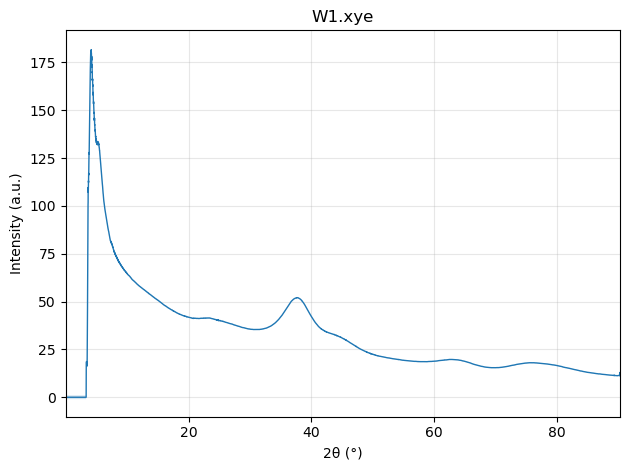

In [49]:
# plot_xye.py
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def plot_xye(path, xlabel="2θ (°)", logy=False, show_err=True):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"{path} not found")

    # Try x, y, e; fallback to x, y
    try:
        x, y, e = np.loadtxt(path, comments=("#", "!", "%", ";"), unpack=True, ndmin=2)
    except ValueError:
        x, y = np.loadtxt(path, comments=("#", "!", "%", ";"), unpack=True, ndmin=2)
        e = None

    fig, ax = plt.subplots()
    ax.plot(x, y, lw=1)
    if show_err and e is not None:
        ax.fill_between(x, y - e, y + e, alpha=0.2, linewidth=0)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Intensity (a.u.)")
    ax.set_title(path.name)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0)
    if logy:
        ax.set_yscale("log")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    import sys
    # Ignore notebook/ipy flags like "--f=..."
    candidates = [a for a in sys.argv[1:] if not a.startswith("-")]
    default_path = "/Users/shane/repos/boicl_crystal_phase_isolation/W_xrd_idex/W1.xye"
    target = candidates[0] if candidates else default_path
    plot_xye(target)
